# BMI Image Dataset EDA

This notebook performs exploratory data analysis for the BMI prediction final project. It checks the provided metadata, validates image availability, explores BMI / gender / train-test distributions, inspects image dimensions, and creates a cleaned manifest for model training.

## 1. Setup

In [1]:
from pathlib import Path
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image, ImageOps

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
# The notebook lives in Final project/. The data is stored one level up under data/raw/bmi/.
PROJECT_DIR = Path.cwd()
ROOT_DIR = PROJECT_DIR.parent if PROJECT_DIR.name.lower() == "final project" else PROJECT_DIR

DATA_DIR = ROOT_DIR / "data" / "raw" / "bmi" / "BMI" / "Data"
CSV_PATH = DATA_DIR / "data.csv"
IMAGE_DIR = DATA_DIR / "Images"

print("Project dir:", PROJECT_DIR)
print("Root dir:   ", ROOT_DIR)
print("CSV path:   ", CSV_PATH)
print("Image dir:  ", IMAGE_DIR)

assert CSV_PATH.exists(), f"Missing CSV: {CSV_PATH}"
assert IMAGE_DIR.exists(), f"Missing image directory: {IMAGE_DIR}"

Project dir: /Users/jiayingzhong/Desktop/ML_2/Final project
Root dir:    /Users/jiayingzhong/Desktop/ML_2
CSV path:    /Users/jiayingzhong/Desktop/ML_2/data/raw/bmi/BMI/Data/data.csv
Image dir:   /Users/jiayingzhong/Desktop/ML_2/data/raw/bmi/BMI/Data/Images


## 2. Load Metadata

In [3]:
df = pd.read_csv(CSV_PATH)

# The first column in this dataset is an unnamed row index. Keep a stable id, then remove the duplicate index column.
if "Unnamed: 0" in df.columns:
    df = df.rename(columns={"Unnamed: 0": "row_id"})
else:
    df.insert(0, "row_id", np.arange(len(df)))

df["image_path"] = df["name"].apply(lambda x: IMAGE_DIR / str(x))
df["image_exists"] = df["image_path"].apply(lambda p: p.exists())
df["split"] = np.where(df["is_training"].astype(int).eq(1), "train", "test")

df.head()

,row_id,bmi,gender,is_training,name,image_path,image_exists,split
0,0,34.207396,Male,1,img_0.bmp,/Users/jiayingzhong/Desktop/ML_2/data/raw/bmi/...,True,train
1,1,26.453720,Male,1,img_1.bmp,/Users/jiayingzhong/Desktop/ML_2/data/raw/bmi/...,True,train
2,2,34.967561,Female,1,img_2.bmp,/Users/jiayingzhong/Desktop/ML_2/data/raw/bmi/...,True,train
3,3,22.044766,Female,1,img_3.bmp,/Users/jiayingzhong/Desktop/ML_2/data/raw/bmi/...,True,train
4,4,37.758789,Female,1,img_4.bmp,/Users/jiayingzhong/Desktop/ML_2/data/raw/bmi/...,False,train


In [4]:
print("Rows, columns:", df.shape)
display(df.dtypes.to_frame("dtype"))
display(df.describe(include="all"))

Rows, columns: (4206, 8)


,dtype
row_id,int64
bmi,float64
gender,str
is_training,int64
name,str
image_path,object
image_exists,bool
split,str


,row_id,bmi,gender,is_training,name,image_path,image_exists,split
count,4206.000000,4206.000000,4206,4206.000000,4206,4206,4206,4206
unique,NaN,NaN,2,NaN,4206,4206,2,2
top,NaN,NaN,Male,NaN,img_0.bmp,/Users/jiayingzhong/Desktop/ML_2/data/raw/bmi/...,True,train
freq,NaN,NaN,2438,NaN,1,1,3962,3368
mean,2102.500000,32.796210,NaN,0.800761,NaN,NaN,NaN,NaN
std,1214.311945,8.299130,NaN,0.399476,NaN,NaN,NaN,NaN
min,0.000000,17.716216,NaN,0.000000,NaN,NaN,NaN,NaN
25%,1051.250000,26.541837,NaN,1.000000,NaN,NaN,NaN,NaN
50%,2102.500000,31.323409,NaN,1.000000,NaN,NaN,NaN,NaN
75%,3153.750000,37.577261,NaN,1.000000,NaN,NaN,NaN,NaN


## 3. Data Quality Checks

In [5]:
quality = pd.DataFrame({
    "missing_values": df.isna().sum(),
    "missing_rate": df.isna().mean().round(4),
    "unique_values": df.nunique(dropna=True),
})
display(quality)

image_files = sorted(IMAGE_DIR.glob("*.bmp"))
image_file_names = {p.name for p in image_files}
metadata_names = set(df["name"].astype(str))
orphan_images = sorted(image_file_names - metadata_names)

print("Duplicate image names:", df["name"].duplicated().sum())
print("Metadata rows without image files:", (~df["image_exists"]).sum())
print("BMP files in image directory:", len(image_files))
print("Image files not referenced in metadata:", len(orphan_images))

missing_images = df.loc[~df["image_exists"], ["row_id", "name", "bmi", "gender", "split"]]
display(missing_images.head(20))
print("First orphan image files:", orphan_images[:20])

,missing_values,missing_rate,unique_values
row_id,0,0.0,4206
bmi,0,0.0,1861
gender,0,0.0,2
is_training,0,0.0,2
name,0,0.0,4206
image_path,0,0.0,4206
image_exists,0,0.0,2
split,0,0.0,2


Duplicate image names: 0
Metadata rows without image files: 244
BMP files in image directory: 3963
Image files not referenced in metadata: 1


,row_id,name,bmi,gender,split
4,4,img_4.bmp,37.758789,Female,train
5,5,img_5.bmp,24.886475,Female,train
40,40,img_40.bmp,39.575905,Male,train
86,86,img_86.bmp,54.123702,Female,train
93,93,img_93.bmp,27.464398,Female,train
112,112,img_112.bmp,39.191165,Male,train
113,113,img_113.bmp,35.122878,Male,train
238,238,img_238.bmp,32.887057,Male,train
239,239,img_239.bmp,27.405881,Male,train
300,300,img_300.bmp,36.868444,Male,train


First orphan image files: ['img_3827(1).bmp']


In [6]:
# Keep only rows that can actually be used by an image model.
eda_df = df[df["image_exists"]].copy().reset_index(drop=True)

print("Original metadata rows:", len(df))
print("Usable rows with images:", len(eda_df))
print("Dropped rows without images:", len(df) - len(eda_df))

Original metadata rows: 4206
Usable rows with images: 3962
Dropped rows without images: 244


## 4. Target Distribution: BMI

,bmi
count,3962.000000
mean,32.674278
std,8.272575
min,17.716216
1%,20.157697
5%,22.237755
10%,23.707598
25%,26.443866
50%,31.166739
75%,37.492724


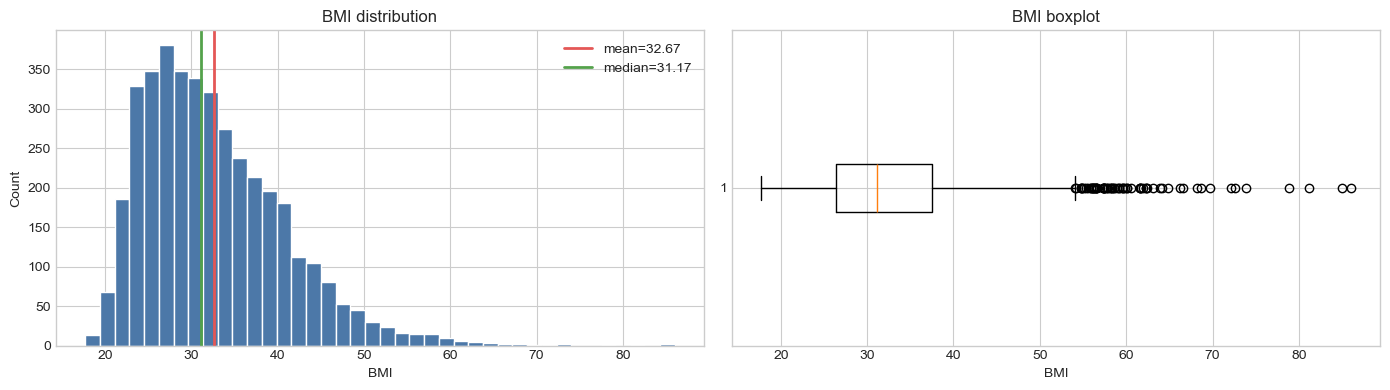

In [7]:
display(eda_df["bmi"].describe(percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]).to_frame())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(eda_df["bmi"], bins=40, color="#4C78A8", edgecolor="white")
axes[0].axvline(eda_df["bmi"].mean(), color="#E45756", linewidth=2, label=f"mean={eda_df['bmi'].mean():.2f}")
axes[0].axvline(eda_df["bmi"].median(), color="#54A24B", linewidth=2, label=f"median={eda_df['bmi'].median():.2f}")
axes[0].set_title("BMI distribution")
axes[0].set_xlabel("BMI")
axes[0].set_ylabel("Count")
axes[0].legend()

axes[1].boxplot(eda_df["bmi"], vert=False)
axes[1].set_title("BMI boxplot")
axes[1].set_xlabel("BMI")

plt.tight_layout()
plt.show()

,count
bmi_category,
underweight,7
normal,663
overweight,1087
obese,2205


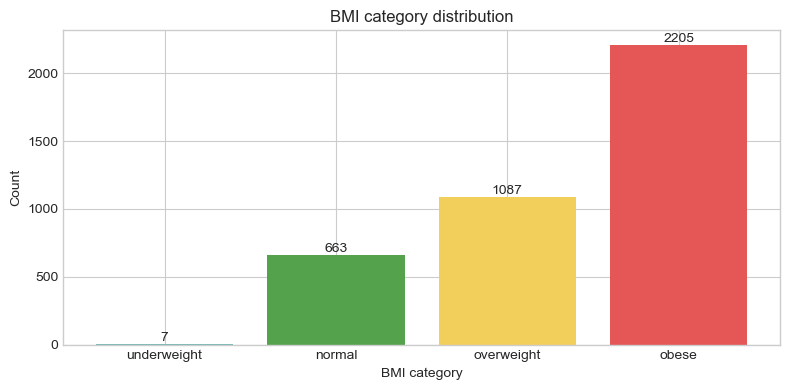

In [8]:
def bmi_category(bmi):
    if bmi < 18.5:
        return "underweight"
    if bmi < 25:
        return "normal"
    if bmi < 30:
        return "overweight"
    return "obese"

eda_df["bmi_category"] = eda_df["bmi"].apply(bmi_category)

cat_order = ["underweight", "normal", "overweight", "obese"]
cat_counts = eda_df["bmi_category"].value_counts().reindex(cat_order).fillna(0).astype(int)
display(cat_counts.to_frame("count"))

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(cat_counts.index, cat_counts.values, color=["#72B7B2", "#54A24B", "#F2CF5B", "#E45756"])
ax.set_title("BMI category distribution")
ax.set_xlabel("BMI category")
ax.set_ylabel("Count")
for i, value in enumerate(cat_counts.values):
    ax.text(i, value, str(value), ha="center", va="bottom")
plt.tight_layout()
plt.show()

## 5. Split and Gender Analysis

In [9]:
split_summary = eda_df.groupby("split").agg(
    n=("bmi", "size"),
    mean_bmi=("bmi", "mean"),
    median_bmi=("bmi", "median"),
    std_bmi=("bmi", "std"),
    min_bmi=("bmi", "min"),
    max_bmi=("bmi", "max"),
).round(3)
display(split_summary)

gender_summary = eda_df.groupby("gender").agg(
    n=("bmi", "size"),
    mean_bmi=("bmi", "mean"),
    median_bmi=("bmi", "median"),
    std_bmi=("bmi", "std"),
).round(3)
display(gender_summary)

display(pd.crosstab(eda_df["split"], eda_df["gender"], margins=True))

,n,mean_bmi,median_bmi,std_bmi,min_bmi,max_bmi
split,,,,,,
test,752,33.698,31.947,9.220,18.651,85.987
train,3210,32.434,30.996,8.017,17.716,81.212


,n,mean_bmi,median_bmi,std_bmi
gender,,,,
Female,1608,32.775,31.474,8.625
Male,2354,32.606,31.001,8.024


gender,Female,Male,All
split,,,
test,325,427,752
train,1283,1927,3210
All,1608,2354,3962


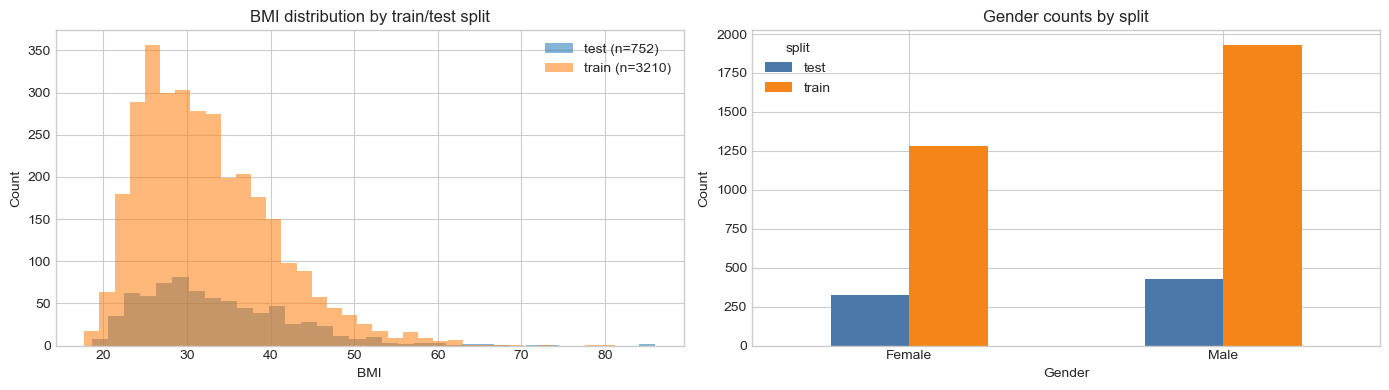

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for split, group in eda_df.groupby("split"):
    axes[0].hist(group["bmi"], bins=35, alpha=0.55, label=f"{split} (n={len(group)})")
axes[0].set_title("BMI distribution by train/test split")
axes[0].set_xlabel("BMI")
axes[0].set_ylabel("Count")
axes[0].legend()

gender_counts = pd.crosstab(eda_df["gender"], eda_df["split"])
gender_counts.plot(kind="bar", ax=axes[1], color=["#4C78A8", "#F58518"])
axes[1].set_title("Gender counts by split")
axes[1].set_xlabel("Gender")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

## 6. Image Inspection

In [ ]:
image_records = []

for idx, row in eda_df.iterrows():
    path = row["image_path"]
    try:
        with Image.open(path) as img:
            image_records.append({
                "row_id": row["row_id"],
                "name": row["name"],
                "width": img.width,
                "height": img.height,
                "mode": img.mode,
            })
    except Exception as exc:
        image_records.append({
            "row_id": row["row_id"],
            "name": row["name"],
            "width": np.nan,
            "height": np.nan,
            "mode": "error",
            "error": str(exc),
        })

image_df = pd.DataFrame(image_records)
eda_df = eda_df.merge(image_df, on=["row_id", "name"], how="left")
eda_df["aspect_ratio"] = eda_df["width"] / eda_df["height"]
eda_df["pixels"] = eda_df["width"] * eda_df["height"]

display(eda_df[["width", "height", "aspect_ratio", "p"
"xels"]].describe().round(2))
display(eda_df["mode"].value_counts(dropna=False).to_frame("count"))

,width,height,aspect_ratio,pixels
count,3962.00,3962.00,3962.00,3962.00
mean,293.39,364.52,0.82,143756.20
std,170.87,221.00,0.10,169440.82
min,41.00,52.00,0.50,2132.00
25%,159.00,193.00,0.75,30954.00
50%,249.00,306.00,0.81,76574.50
75%,392.00,482.00,0.88,187383.00
max,900.00,1222.00,1.29,1028924.00


,count
mode,
RGB,3954
P,8


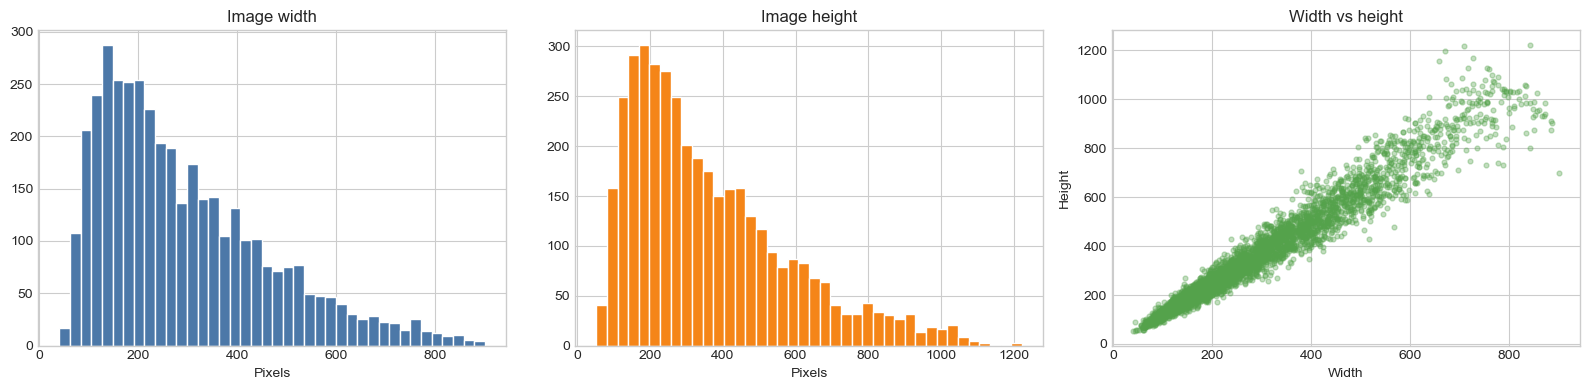

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(eda_df["width"].dropna(), bins=40, color="#4C78A8", edgecolor="white")
axes[0].set_title("Image width")
axes[0].set_xlabel("Pixels")

axes[1].hist(eda_df["height"].dropna(), bins=40, color="#F58518", edgecolor="white")
axes[1].set_title("Image height")
axes[1].set_xlabel("Pixels")

axes[2].scatter(eda_df["width"], eda_df["height"], s=12, alpha=0.35, color="#54A24B")
axes[2].set_title("Width vs height")
axes[2].set_xlabel("Width")
axes[2].set_ylabel("Height")

plt.tight_layout()
plt.show()

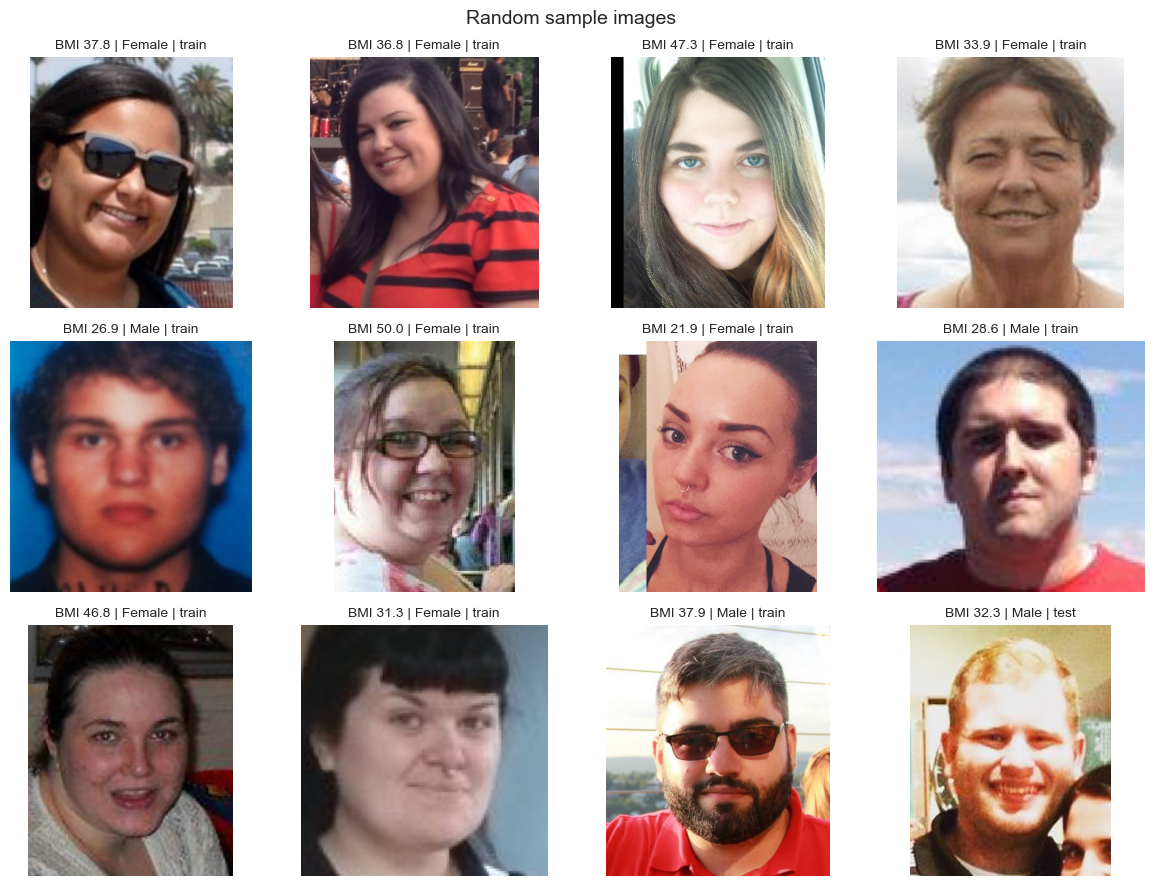

In [13]:
def show_samples(sample_df, title, n=12):
    sample_df = sample_df.sample(min(n, len(sample_df)), random_state=SEED)
    cols = 4
    rows = int(np.ceil(len(sample_df) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(12, 3 * rows))
    axes = np.array(axes).reshape(-1)
    for ax, (_, row) in zip(axes, sample_df.iterrows()):
        img = Image.open(row["image_path"]).convert("RGB")
        ax.imshow(img)
        ax.set_title(f"BMI {row['bmi']:.1f} | {row['gender']} | {row['split']}", fontsize=10)
        ax.axis("off")
    for ax in axes[len(sample_df):]:
        ax.axis("off")
    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

show_samples(eda_df, "Random sample images")

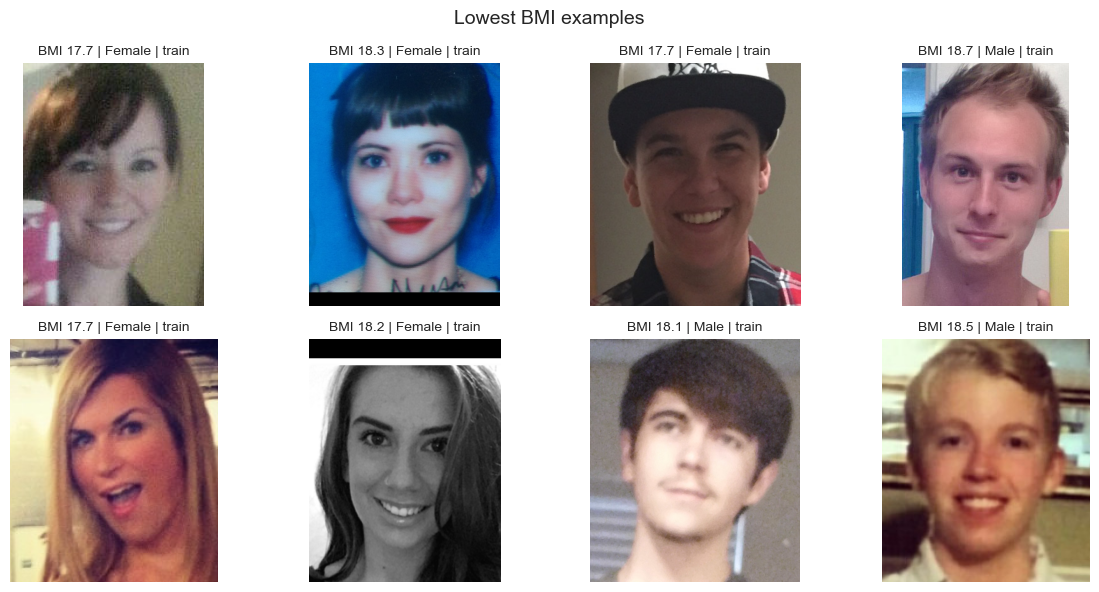

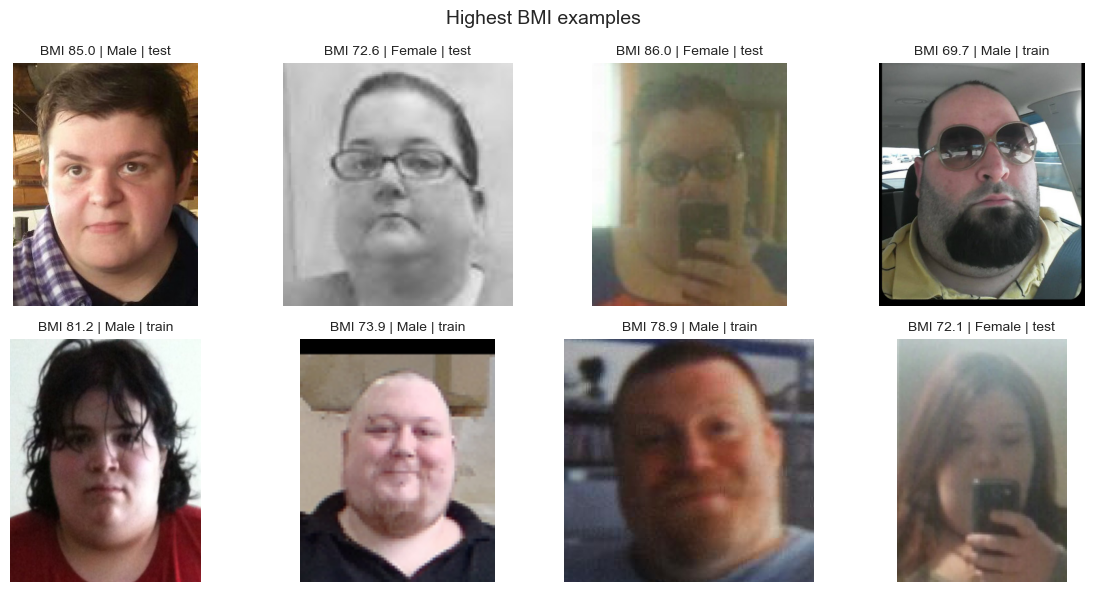

In [14]:
# Visual sanity check across BMI ranges.
low = eda_df.nsmallest(8, "bmi")
high = eda_df.nlargest(8, "bmi")

show_samples(low, "Lowest BMI examples", n=8)
show_samples(high, "Highest BMI examples", n=8)

## 7. Baseline Metrics for Context

Before training a deep model, use simple baselines on the provided train/test split. A useful image model must beat these baselines on the same test set.

In [15]:
train_df = eda_df[eda_df["split"] == "train"].copy()
test_df = eda_df[eda_df["split"] == "test"].copy()

def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot else np.nan
    return {"MAE": mae, "RMSE": rmse, "R2": r2}

global_mean_pred = np.full(len(test_df), train_df["bmi"].mean())
global_median_pred = np.full(len(test_df), train_df["bmi"].median())

gender_means = train_df.groupby("gender")["bmi"].mean().to_dict()
fallback = train_df["bmi"].mean()
gender_mean_pred = test_df["gender"].map(gender_means).fillna(fallback).to_numpy()

baseline_results = pd.DataFrame({
    "train_mean": regression_metrics(test_df["bmi"], global_mean_pred),
    "train_median": regression_metrics(test_df["bmi"], global_median_pred),
    "gender_train_mean": regression_metrics(test_df["bmi"], gender_mean_pred),
}).T.round(4)

display(baseline_results)

,MAE,RMSE,R2
train_mean,7.0400,9.3000,-0.0188
train_median,7.0655,9.6017,-0.0860
gender_train_mean,7.0500,9.3112,-0.0213


## 8. Save Clean Manifest

In [16]:
OUT_DIR = ROOT_DIR / "Final project" / "outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

manifest_cols = [
    "row_id", "name", "image_path", "bmi", "bmi_category", "gender", "is_training", "split",
    "width", "height", "mode", "aspect_ratio", "pixels"
]
manifest = eda_df[manifest_cols].copy()
manifest["image_path"] = manifest["image_path"].astype(str)

manifest_path = OUT_DIR / "bmi_clean_manifest.csv"
manifest.to_csv(manifest_path, index=False)

print(f"Saved clean manifest: {manifest_path}")
display(manifest.head())

Saved clean manifest: /Users/jiayingzhong/Desktop/ML_2/Final project/outputs/bmi_clean_manifest.csv


,row_id,name,image_path,bmi,bmi_category,gender,is_training,split,width,height,mode,aspect_ratio,pixels
0,0,img_0.bmp,/Users/jiayingzhong/Desktop/ML_2/data/raw/bmi/...,34.207396,obese,Male,1,train,164,176,RGB,0.931818,28864
1,1,img_1.bmp,/Users/jiayingzhong/Desktop/ML_2/data/raw/bmi/...,26.453720,overweight,Male,1,train,150,173,RGB,0.867052,25950
2,2,img_2.bmp,/Users/jiayingzhong/Desktop/ML_2/data/raw/bmi/...,34.967561,obese,Female,1,train,226,251,RGB,0.900398,56726
3,3,img_3.bmp,/Users/jiayingzhong/Desktop/ML_2/data/raw/bmi/...,22.044766,normal,Female,1,train,97,126,RGB,0.769841,12222
4,6,img_6.bmp,/Users/jiayingzhong/Desktop/ML_2/data/raw/bmi/...,25.845588,overweight,Female,1,train,87,115,RGB,0.756522,10005


## 9. Initial EDA Notes

Fill this section after running the notebook:

- Number of metadata rows:
- Number of usable image rows:
- Missing image rows:
- Train/test split size:
- Gender balance:
- BMI range and skew:
- Image size variability:
- Important risks for modeling:
  - BMI distribution is imbalanced toward higher values.
  - Missing images should be excluded from image training.
  - Images have variable dimensions and modes, so preprocessing should standardize RGB conversion and resize/crop policy.
  - Report metrics on the provided test split and compare against simple mean/median baselines.